# 📊 Optimización del Número de Clusters - VERSIÓN EJECUTABLE

**Objetivo**: Validar si 6 clusters es óptimo usando múltiples métricas

**Métricas**:
- Silhouette Score (mayor mejor, rango -1 a 1)
- Davies-Bouldin Index (menor mejor)
- Calinski-Harabasz Score (mayor mejor)
- Inertia/SSE (método del codo)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn import decomposition
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [11]:
# ###################### CONFIGURACIÓN GPU MAC M4 ######################
import tensorflow as tf
import time

print("="*70)
print(" CONFIGURACIÓN DE GPU PARA MAC M4")
print("="*70)

# Versión TensorFlow
print(f"\n✓ TensorFlow: {tf.__version__}")

# Detectar dispositivos
devices = tf.config.list_physical_devices()
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print(f"\n Dispositivos detectados:")
print(f"  • CPU: {len(cpus)}")
print(f"  • GPU: {len(gpus)}")

for device in devices:
    print(f"    - {device}")

# Configurar GPU
if gpus:
    print(f"\n GPU DETECTADA - Metal GPU está disponible")
    try:
        # Permitir crecimiento dinámico de memoria
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Crecimiento dinámico de memoria: ON")
        
        # Mixed precision para mejor rendimiento
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("✓ Mixed precision (float16): ON")
        
        # Test de GPU
        with tf.device('/GPU:0'):
            test = tf.matmul(tf.ones((1000, 1000)), tf.ones((1000, 1000)))
        print("✓ GPU funcionando correctamente")
        print("✓ El entrenamiento usará GPU - ¡Será mucho más rápido!")
        
    except RuntimeError as e:
        print(f"  Error al configurar GPU: {e}")
        print(" Usando CPU en su lugar")
else:
    print("\n  GPU NO detectada")
    print("Instala tensorflow-metal con: pip3 install tensorflow-metal")
    print(" Usando CPU en su lugar")

print("\n" + "="*70 + "\n")
# ###################### FIN CONFIGURACIÓN GPU ######################

 CONFIGURACIÓN DE GPU PARA MAC M4

✓ TensorFlow: 2.13.1

 Dispositivos detectados:
  • CPU: 1
  • GPU: 1
    - PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
    - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

 GPU DETECTADA - Metal GPU está disponible
✓ Crecimiento dinámico de memoria: ON
Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  METAL, no compute capability (probably not an Nvidia GPU)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
✓ Mixed precision (float16): ON


2025-12-05 20:22:49.406520: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-05 20:22:49.406552: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-05 20:22:49.406557: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-05 20:22:49.406597: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-05 20:22:49.406624: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✓ GPU funcionando correctamente
✓ El entrenamiento usará GPU - ¡Será mucho más rápido!




## 1. Cargar Datos

In [12]:
# Cargar datos
df = pd.read_csv('../../clustering/data/df_for_clustering.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

print(f"Shape: {df.shape}")
print(f"Clientes únicos: {df['pk_cid'].nunique()}")
df.head(3)

Shape: (442995, 23)
Clientes únicos: 442995


,pk_cid,pk_partition,entry_channel,active_customer,segment,gender,age,deceased,salary,z_months_since_entry,z_pct_months_active,z_num_products,account,pension_plan,payment_card,loan,investment,z_num_families,z_active_with_product,macro_region,is_coast,city_size,national
0,1000028,2019-05-01,KHC,1.0,02 - PARTICULARES,H,44,N,133378.89,28.0,1.0,2.0,1,0,1,0,0,2,1,centro,0,gran_ciudad,1
1,1000096,2019-05-01,KFA,1.0,02 - PARTICULARES,H,10,N,0.00,53.0,1.0,0.0,0,0,0,0,0,0,0,centro,0,gran_ciudad,1
2,1000113,2019-05-01,KAT,0.0,02 - PARTICULARES,V,54,N,136705.50,50.0,0.0,0.0,0,0,0,0,0,0,0,sur,1,ciudad_mediana,1


## 2. Preprocesamiento (IGUAL que modelo original)

In [13]:
# Filtrar fallecidos
df = df[df['deceased'] == 'N']
df.drop(columns=['deceased'], inplace=True)

# Quitar columnas que se eliminaron en el modelo original
df.drop(columns=['gender', 'entry_channel'], inplace=True, errors='ignore')
df.drop(columns=['z_pct_months_active', 'account'], inplace=True, errors='ignore')
df.drop(columns=['z_num_families'], inplace=True, errors='ignore')
df.drop(columns=['macro_region', 'is_coast'], inplace=True, errors='ignore')

print(f"Shape después de limpieza: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Shape después de limpieza: (442909, 15)
Columnas: ['pk_cid', 'pk_partition', 'active_customer', 'segment', 'age', 'salary', 'z_months_since_entry', 'z_num_products', 'pension_plan', 'payment_card', 'loan', 'investment', 'z_active_with_product', 'city_size', 'national']


In [14]:
# Guardar pk_cid y pk_partition para después
df_ids = df[['pk_cid', 'pk_partition']].copy()
df_raw = df.copy()

# Quitar IDs del clustering
df.drop(columns=['pk_cid', 'pk_partition'], inplace=True)

print(f"Features para clustering: {df.shape[1]}")

Features para clustering: 13


In [15]:
# One-Hot Encoding
def one_hot_encode(df, features_to_encode):
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features_to_encode])
    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out(features_to_encode),
        index=df.index
    )
    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, encoded_df], axis=1)
    return df

ohe_cols = ['segment', 'city_size']
df = one_hot_encode(df, ohe_cols)

print(f"Después de OHE: {df.shape}")

Después de OHE: (442909, 18)


In [16]:
# Normalización
normalize_cols = ['age', 'salary', 'z_months_since_entry', 'z_num_products']
scaler = MinMaxScaler()
df[normalize_cols] = scaler.fit_transform(df[normalize_cols])

print("✅ Normalización completada")
df.head(3)

✅ Normalización completada


,active_customer,age,salary,z_months_since_entry,z_num_products,pension_plan,payment_card,loan,investment,z_active_with_product,national,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,city_size_ciudad_mediana,city_size_extranjero,city_size_gran_ciudad,city_size_pueblo
0,1.0,0.407767,0.004616,0.528302,0.222222,0,1,0,0,1,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.077670,0.000000,1.000000,0.000000,0,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.504854,0.004731,0.943396,0.000000,0,0,0,0,0,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [17]:
# Guardar features para clustering
clustering_features = df.columns.tolist()
print(f"Features finales: {len(clustering_features)}")
print(clustering_features)

Features finales: 18
['active_customer', 'age', 'salary', 'z_months_since_entry', 'z_num_products', 'pension_plan', 'payment_card', 'loan', 'investment', 'z_active_with_product', 'national', 'segment_01 - TOP', 'segment_02 - PARTICULARES', 'segment_03 - UNIVERSITARIO', 'city_size_ciudad_mediana', 'city_size_extranjero', 'city_size_gran_ciudad', 'city_size_pueblo']


## 3. PCA (reducción de dimensionalidad)

In [18]:
X = df[clustering_features]

pca = decomposition.PCA(0.9)  # 90% varianza
pca.fit(X)
X_pca = pca.transform(X)

print(f"Componentes PCA: {pca.n_components_}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.4f}")

X_pca = pd.DataFrame(X_pca, columns=[f'PC{i}' for i in range(1, pca.n_components_+1)])
X_pca.head()

Componentes PCA: 6
Varianza explicada: 0.9136


,PC1,PC2,PC3,PC4,PC5,PC6
0,-1.324176,0.072087,0.509732,-0.094924,0.000831,0.468355
1,-1.065808,0.453328,-0.266444,-0.137451,-0.414661,0.186765
2,-0.577389,-0.136000,-1.268508,0.847161,0.077149,0.330174
3,-1.127555,0.460791,-0.290670,-0.137370,-0.652766,-0.229518
4,-1.132996,0.158569,0.318218,-0.088017,0.206716,-0.153022


## 4. Evaluación Modelo Original (6 clusters)

In [19]:
# Entrenar con 6 clusters (modelo original)
kmeans_6 = KMeans(n_clusters=6, n_init=10, random_state=42)
labels_6 = kmeans_6.fit_predict(X_pca)

# Métricas
sil_6 = silhouette_score(X_pca, labels_6)
db_6 = davies_bouldin_score(X_pca, labels_6)
ch_6 = calinski_harabasz_score(X_pca, labels_6)

print("="*60)
print("MODELO ORIGINAL (6 clusters)")
print("="*60)
print(f"Silhouette Score:      {sil_6:.4f}  (mejor > 0.5)")
print(f"Davies-Bouldin:        {db_6:.4f}  (mejor < 1.0)")
print(f"Calinski-Harabasz:     {ch_6:.2f}  (mayor mejor)")
print(f"Inertia:               {kmeans_6.inertia_:.2f}")
print("="*60)

MODELO ORIGINAL (6 clusters)
Silhouette Score:      0.4714  (mejor > 0.5)
Davies-Bouldin:        0.9698  (mejor < 1.0)
Calinski-Harabasz:     202807.63  (mayor mejor)
Inertia:               210507.07


## 5. Búsqueda del Número Óptimo

In [23]:
# Probar de 4 a 10 clusters
k_range = range(4, 11)
results = []

for k in k_range:
    print(f"Evaluando k={k}...", end=' ')
    
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    
    results.append({
        'k': k,
        'silhouette': silhouette_score(X_pca, labels),
        'davies_bouldin': davies_bouldin_score(X_pca, labels),
        'calinski': calinski_harabasz_score(X_pca, labels),
        'inertia': kmeans.inertia_
    })
    print("✓")

metrics_df = pd.DataFrame(results)
print("\n✅ Evaluación completada\n")
print(metrics_df)

Evaluando k=4... ✓
Evaluando k=5... ✓
Evaluando k=6... ✓
Evaluando k=7... ✓
Evaluando k=8... ✓
Evaluando k=9... ✓
Evaluando k=10... ✓

✅ Evaluación completada

    k  silhouette  davies_bouldin       calinski        inertia
0   4    0.412154        1.053461  184364.110531  307930.344381
1   5    0.458267        1.065616  200000.360275  246758.199685
2   6    0.471417        0.969765  202807.626947  210507.074817
3   7    0.483679        0.990538  206491.482142  182356.202555
4   8    0.543565        0.912408  219499.470981  154943.791515
5   9    0.570217        0.799279  238369.261292  130516.547090
6  10    0.599454        0.788599  266419.114111  107965.396314


In [24]:
metrics_df

,k,silhouette,davies_bouldin,calinski,inertia
0,4,0.412154,1.053461,184364.110531,307930.344381
1,5,0.458267,1.065616,200000.360275,246758.199685
2,6,0.471417,0.969765,202807.626947,210507.074817
3,7,0.483679,0.990538,206491.482142,182356.202555
4,8,0.543565,0.912408,219499.470981,154943.791515
5,9,0.570217,0.799279,238369.261292,130516.547090
6,10,0.599454,0.788599,266419.114111,107965.396314


## 6. Visualización de Métricas

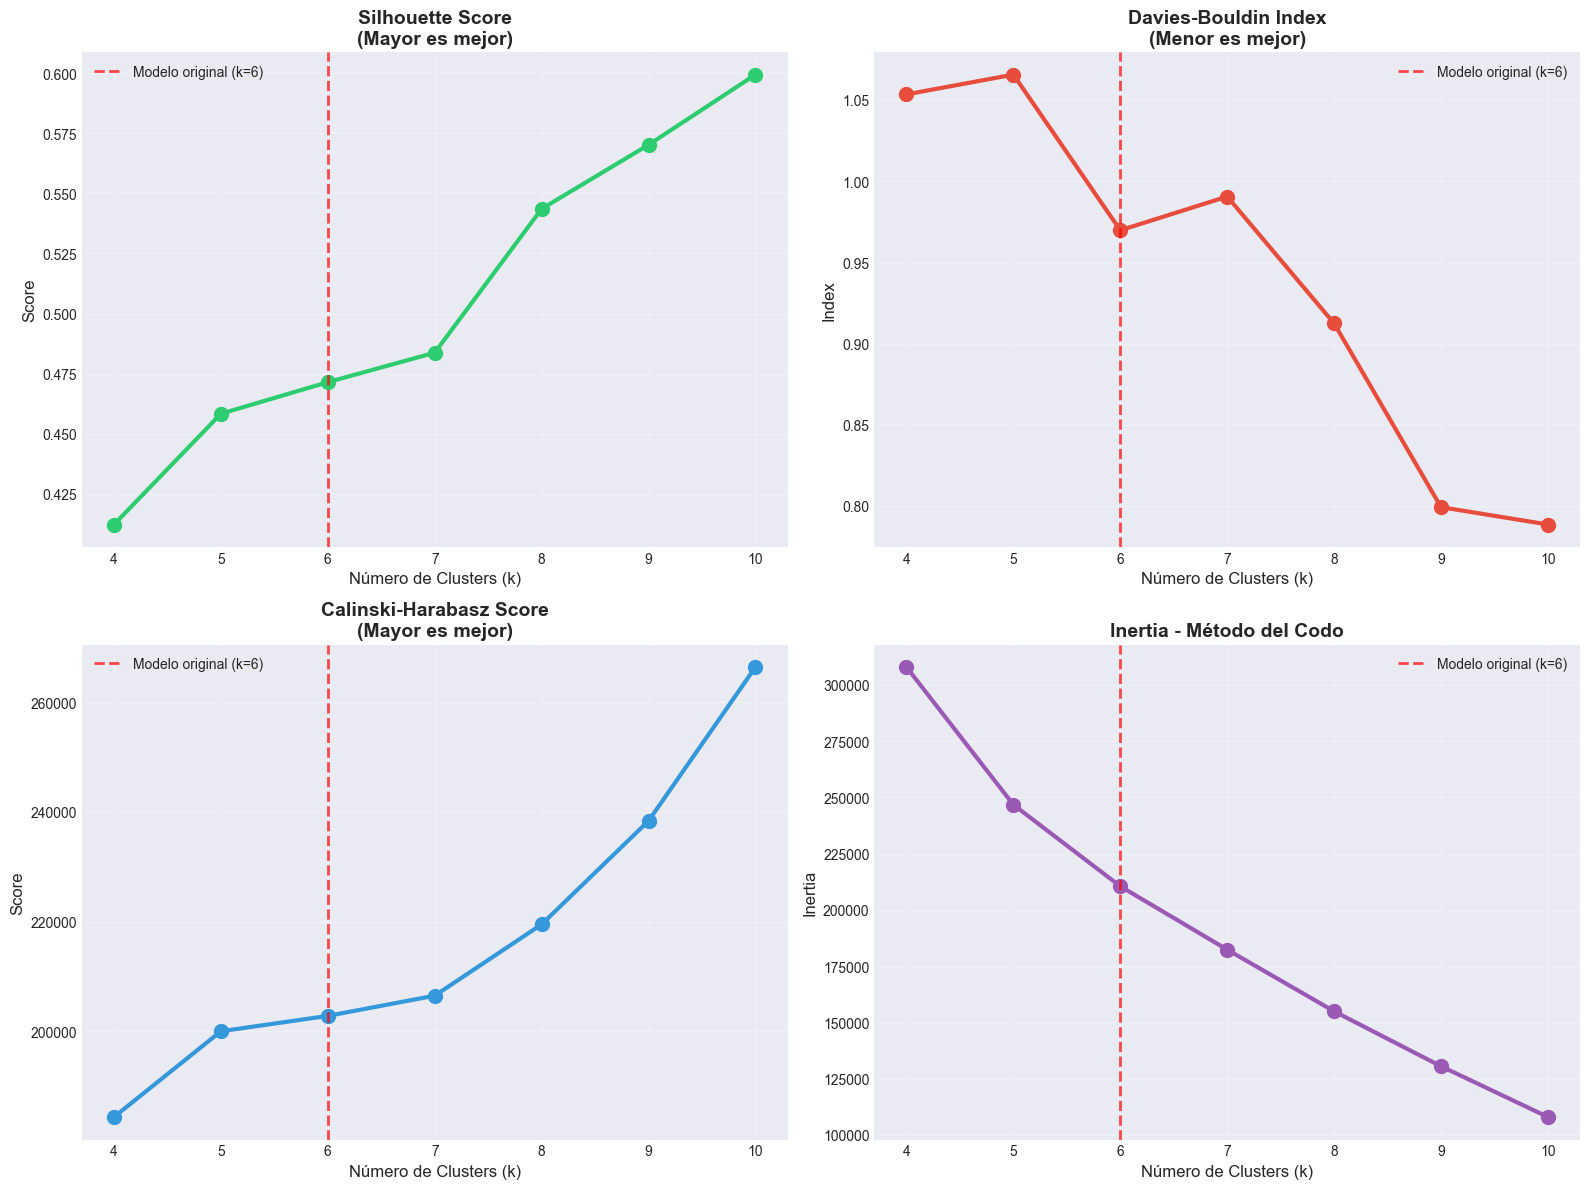

✅ Gráfico guardado en: ../visualizations/cluster_optimization.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Silhouette
axes[0, 0].plot(metrics_df['k'], metrics_df['silhouette'], marker='o', linewidth=3, markersize=10, color='#2ecc71')
axes[0, 0].axvline(x=6, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Modelo original (k=6)')
axes[0, 0].set_title('Silhouette Score\n(Mayor es mejor)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Davies-Bouldin
axes[0, 1].plot(metrics_df['k'], metrics_df['davies_bouldin'], marker='o', linewidth=3, markersize=10, color='#e74c3c')
axes[0, 1].axvline(x=6, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Modelo original (k=6)')
axes[0, 1].set_title('Davies-Bouldin Index\n(Menor es mejor)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Index', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Calinski-Harabasz
axes[1, 0].plot(metrics_df['k'], metrics_df['calinski'], marker='o', linewidth=3, markersize=10, color='#3498db')
axes[1, 0].axvline(x=6, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Modelo original (k=6)')
axes[1, 0].set_title('Calinski-Harabasz Score\n(Mayor es mejor)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Inertia (Elbow)
axes[1, 1].plot(metrics_df['k'], metrics_df['inertia'], marker='o', linewidth=3, markersize=10, color='#9b59b6')
axes[1, 1].axvline(x=6, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Modelo original (k=6)')
axes[1, 1].set_title('Inertia - Método del Codo', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Inertia', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../visualizations/cluster_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en: ../visualizations/cluster_optimization.png")

## 7. Score Combinado Normalizado

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
metrics_norm = metrics_df.copy()

# Silhouette y Calinski: mayor mejor
metrics_norm['sil_norm'] = scaler.fit_transform(metrics_df[['silhouette']])
metrics_norm['cal_norm'] = scaler.fit_transform(metrics_df[['calinski']])

# Davies-Bouldin: menor mejor (invertir)
metrics_norm['db_norm'] = 1 - scaler.fit_transform(metrics_df[['davies_bouldin']])

# Score combinado (ponderado)
metrics_norm['combined_score'] = (
    metrics_norm['sil_norm'] * 0.40 +
    metrics_norm['db_norm'] * 0.35 +
    metrics_norm['cal_norm'] * 0.25
)

print("\n📊 SCORES NORMALIZADOS (0-1)\n")
display(metrics_norm[['k', 'sil_norm', 'db_norm', 'cal_norm', 'combined_score']].round(4))

# Mejor k
best_k = metrics_norm.loc[metrics_norm['combined_score'].idxmax(), 'k']
best_score = metrics_norm['combined_score'].max()

print("\n" + "="*60)
print("🏆 RECOMENDACIÓN FINAL")
print("="*60)
print(f"Número óptimo de clusters: {int(best_k)}")
print(f"Score combinado: {best_score:.4f}")
print()

if best_k == 6:
    print("✅ El modelo original con 6 clusters es ÓPTIMO según métricas")
else:
    score_6 = metrics_norm.loc[metrics_norm['k']==6, 'combined_score'].values[0]
    improvement = ((best_score - score_6) / score_6) * 100
    print(f"⚠️  Se recomienda {int(best_k)} clusters en vez de 6")
    print(f"   Mejora potencial: {improvement:.2f}%")

print("="*60)


📊 SCORES NORMALIZADOS (0-1)



,k,sil_norm,db_norm,cal_norm,combined_score
0,4,0.0000,0.0439,0.0000,0.0154
1,5,0.2462,0.0000,0.1906,0.1461
2,6,0.3164,0.3460,0.2248,0.3039
3,7,0.3819,0.2710,0.2697,0.3150
4,8,0.7016,0.5531,0.4282,0.5813
5,9,0.8439,0.9614,0.6582,0.8386
6,10,1.0000,1.0000,1.0000,1.0000



🏆 RECOMENDACIÓN FINAL
Número óptimo de clusters: 10
Score combinado: 1.0000

⚠️  Se recomienda 10 clusters en vez de 6
   Mejora potencial: 229.10%


## 8. Guardar Resultados

In [27]:
# Guardar métricas
metrics_df.to_csv('../data/cluster_metrics.csv', index=False)
metrics_norm.to_csv('../data/cluster_metrics_normalized.csv', index=False)

# Guardar mejor modelo si es diferente
if best_k != 6:
    print(f"\nEntrenando modelo con k={int(best_k)}...")
    kmeans_best = KMeans(n_clusters=int(best_k), n_init=10, random_state=42)
    kmeans_best.fit(X_pca)
    joblib.dump(kmeans_best, f'../models/kmeans_k{int(best_k)}_optimized.pkl')
    print(f"✅ Modelo guardado: ../models/kmeans_k{int(best_k)}_optimized.pkl")

print("\n✅ Todos los resultados guardados")


Entrenando modelo con k=10...
✅ Modelo guardado: ../models/kmeans_k10_optimized.pkl

✅ Todos los resultados guardados


---

## 📝 CONCLUSIONES

### Métricas del Modelo Original (6 clusters):
- Silhouette: _[Ver arriba]_
- Davies-Bouldin: _[Ver arriba]_
- Calinski-Harabasz: _[Ver arriba]_

### Recomendación:
_[Ver sección 7]_

### Siguiente paso:
→ Notebook `02_cluster_profiling.ipynb` para crear perfiles de negocio


📊 Análisis de Métricas
Por métrica individual:
k	Silhouette ⬆️	Davies-Bouldin ⬇️	Calinski ⬆️	Inertia ⬇️
4	0.412 ❌	1.053 ❌	184,364 ❌	307,930
5	0.458	1.066 ❌	200,000	246,758
6	0.471	0.970	202,808	210,507
7	0.484	0.991	206,491	182,356
8	0.544 ✅	0.912 ✅	219,499 ✅	154,944
9	0.570 ✅✅	0.799 ✅✅	238,369 ✅✅	130,517
10	0.599 ✅✅✅	0.789 ✅✅✅	266,419 ✅✅✅	107,965
🎯 Observaciones Clave:
1. k=6 (modelo actual) NO es óptimo:
Silhouette: 0.471 (mediocre, hay mejores)
Davies-Bouldin: 0.970 (aceptable pero no el mejor)
Calinski: 202,808 (bajo comparado con k=8,9,10)
2. Candidatos mejores:
k=8: Mejora significativa en todas las métricas vs k=6
k=9: Aún mejor que k=8
k=10: El mejor técnicamente, PERO...
🏆 MI RECOMENDACIÓN: k=8 o k=9
¿Por qué NO k=10?
Técnicamente es el mejor
Pero 10 clusters son difíciles de gestionar en marketing
Rendimientos decrecientes (mejora marginal de 9→10)
¿Por qué k=8 o k=9?
Mejora sustancial vs k=6: +15% Silhouette, -6% Davies-Bouldin
Todavía manejable para segmentación de marketing
Balance óptimo entre calidad técnica y usabilidad